Trabalho prático, PDI 3D resonancia

In [155]:
#Impotações

import matplotlib.pyplot as plt
import numpy as np
import SimpleITK as sitk
print(sitk.Version())

SimpleITK Version: 2.5.3 (ITK 5.4)
Compiled: Nov 20 2025 23:11:16



Pegar o cainho dos arquivos, ler as imagens, ver os metadados, fazer a conversao para array, escolher a fatia do meio e mostrar essa fatia.

fazer isso para T1 e flair

Image lida com sucesso!!!

Size:  (181, 217, 181)
Spacing:  (1.0, 1.0, 1.0)
Origin:  (0.0, 0.0, 0.0)
Direction:  (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
--------------------------------------------------------------------------------
Imagem foi convertida para array com sucesso!!!

Tipo de dado da Matriz:  uint8
Array shape:  (181, 217, 181)
Altura da imagem:  181
Largura da imagem:  217
Profundidade da imagem:  181
--------------------------------------------------------------------------------


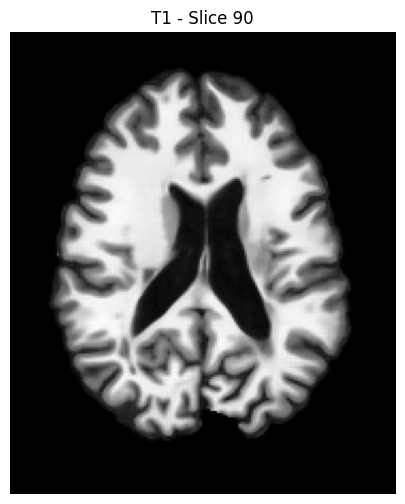

In [156]:
#caminhos dos arquivos
img_path = "../Trabalho1-Descricao-20260407/Imagens_Clinicas/T01C01"
img_filename = "T01C01_t1.nii.gz"
full_img_path = f"{img_path}/{img_filename}"



#Lê a imagem seguindo o caminho
img = sitk.ReadImage(full_img_path)
print("Image lida com sucesso!!!\n")



#Metadados basicos
print("Size: ", img.GetSize())
print("Spacing: ", img.GetSpacing())
print("Origin: ", img.GetOrigin())
print("Direction: ", img.GetDirection())

print("-"*80)



#Conversão da imagem para array
img_array = sitk.GetArrayFromImage(img)
print("Imagem foi convertida para array com sucesso!!!\n")
print("Tipo de dado da Matriz: ", img_array.dtype)
print("Array shape: ", img_array.shape)
print("Altura da imagem: ", img_array.shape[0])
print("Largura da imagem: ", img_array.shape[1])
print("Profundidade da imagem: ", img_array.shape[2])

print("-"*80)



#Mostrar uma fatia da imagem central
slice_img_idx = img_array.shape[0] // 2 #pega a metade da altura


plt.figure(figsize=(6,6))
plt.imshow(img_array[slice_img_idx], cmap="gray")
plt.title(f"T1 - Slice {slice_img_idx}")
plt.axis("off")
plt.show()

Flair lido com sucesso!!!

Size:  (181, 217, 181)
Spacing:  (1.0, 1.0, 1.0)
Origin:  (0.0, 0.0, 0.0)
Direction:  (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
--------------------------------------------------------------------------------
Flair convertido para array com sucesso!!!

Tipo de dado:  uint8
Array shape (181, 217, 181)
Altura da flair 181
Largura da flair 217
Profundidade da flair 181
--------------------------------------------------------------------------------


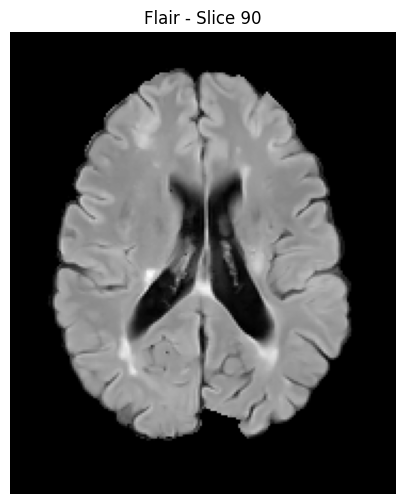

In [157]:
#flair_path = "../Trabalho1-Descricao-20260407/Imagens_Clinicas/T01C01"
flair_filename = "T01C01_flair.nii.gz"

full_flair_path = f"{img_path}/{flair_filename}"


#Lê imagem flair
flair = sitk.ReadImage(full_flair_path)
print("Flair lido com sucesso!!!\n")

#metadados
print("Size: ", flair.GetSize())
print("Spacing: ", flair.GetSpacing())
print("Origin: ", flair.GetOrigin())
print("Direction: ", flair.GetDirection())

print("-"*80)



#Converte flair em array
flair_array = sitk.GetArrayFromImage(flair)
print("Flair convertido para array com sucesso!!!\n")
print("Tipo de dado: ", flair_array.dtype)
print("Array shape", flair_array.shape)
print("Altura da flair", flair_array.shape[0])
print("Largura da flair", flair_array.shape[1])
print("Profundidade da flair", flair_array.shape[2])


print("-"*80)


#mostrar uma fatia flair central 
slice_flair_idx = flair_array.shape[0] // 2 #pega metade da altura

plt.figure(figsize=(6,6))
plt.imshow(flair_array[slice_flair_idx], cmap="gray")
plt.title(f"Flair - Slice {slice_flair_idx}")
plt.axis("off")
plt.show()


Comparando os dois tipos de Ressoancia magnetica
T1 e flair

T1
costuma ser boa para mostrar anatomia geral, contornos estruturais, organização do cerebro.
Então é melhor para ver estruturas, alinhamentos, referencias.

FLAIR
é feita para destacar certas alterações, especialmente em tecidos onde lesões podem aparecer melhor.

Basicamente T1 ajuda a ver a anatomia, e FLAIR ajuda muito a ver lesões.

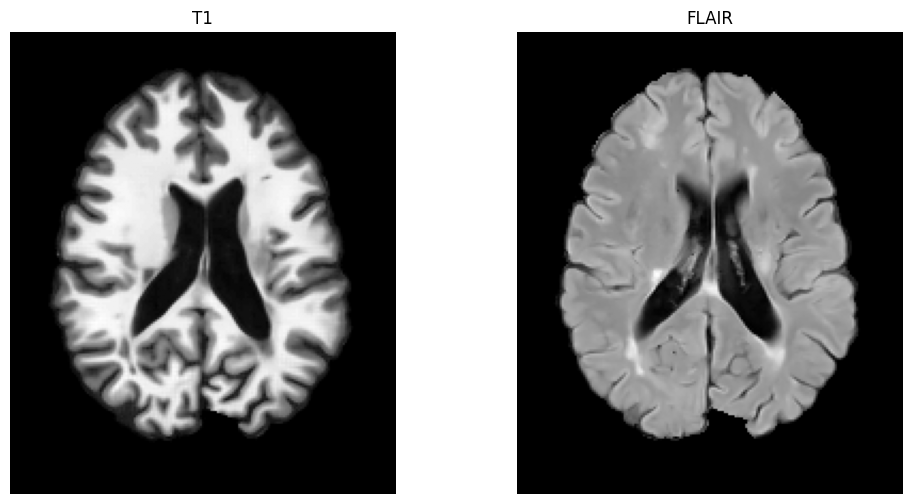

In [158]:
#Comparando lado a lado T1 x flair


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_array[slice_img_idx], cmap="gray")
plt.title("T1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(flair_array[slice_flair_idx], cmap="gray")
plt.title("FLAIR")
plt.axis("off")

plt.show()

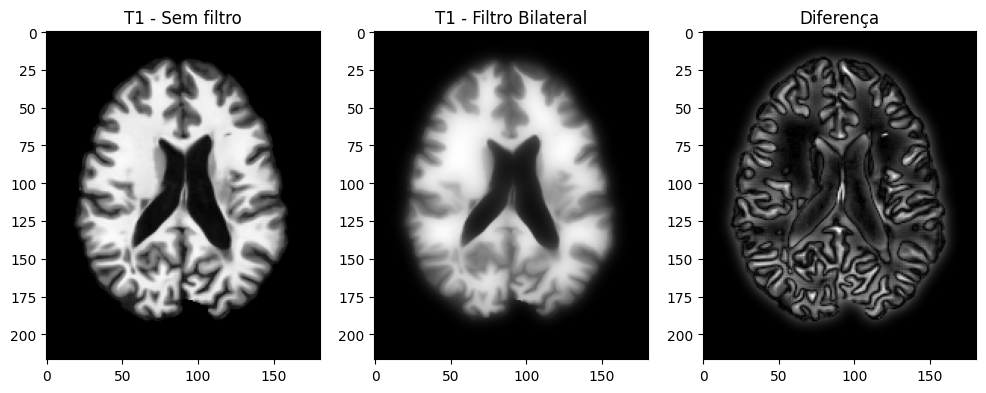

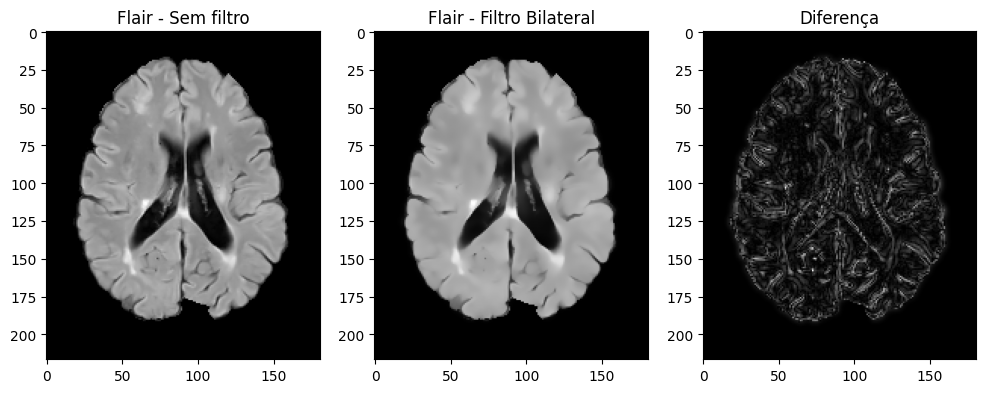

In [159]:
#Passando o filtro da T1 e mostrando a diferença


#pega a fatia e tranforma em itk
noisy_img = sitk.GetImageFromArray(img_array[slice_img_idx].astype("float32"))

#passa o filtro bilateral na fatia
denoised_img = sitk.Bilateral(noisy_img, 5, 30)

#transforma a imagem itk filtrada em array denovo
denoised_img_array = sitk.GetArrayFromImage(denoised_img)

#faz subtraçãp da fatia original e filtrada
G_img = np.abs(img_array[slice_img_idx] - denoised_img_array)

#Mostra as imagens
plt.figure(figsize=[12,12])
plt.subplot(2,3,1)
plt.title("T1 - Sem filtro")
plt.imshow(img_array[slice_img_idx], 'gray')

plt.subplot(2,3,2)
plt.title("T1 - Filtro Bilateral")
plt.imshow(denoised_img_array, 'gray')

plt.subplot(2,3,3)
plt.title("Diferença")
plt.imshow(G_img, 'gray')

#passando o filtragem no flair e mostrando a diferença

#pega a fatia e tranforma em itk
noisy_flair = sitk.GetImageFromArray(flair_array[slice_flair_idx].astype("float32"))

#passa o filtro bilateral na fatia
denoised_flair = sitk.Bilateral(noisy_flair, 2, 20)

#transforma a imagem itk filtrada em array denovo
denoised_flair_array = sitk.GetArrayFromImage(denoised_flair)

#faz subtraçãp da fatia original e filtrada
G_flair = np.abs(flair_array[slice_flair_idx] - denoised_flair_array)


#Mostra as imagens
plt.figure(figsize=[12,12])
plt.subplot(2,3,1)
plt.title("Flair - Sem filtro")
plt.imshow(flair_array[slice_flair_idx], 'gray')

plt.subplot(2,3,2)
plt.title("Flair - Filtro Bilateral")
plt.imshow(denoised_flair_array, 'gray')

plt.subplot(2,3,3)
plt.title("Diferença")
plt.imshow(G_flair, 'gray')

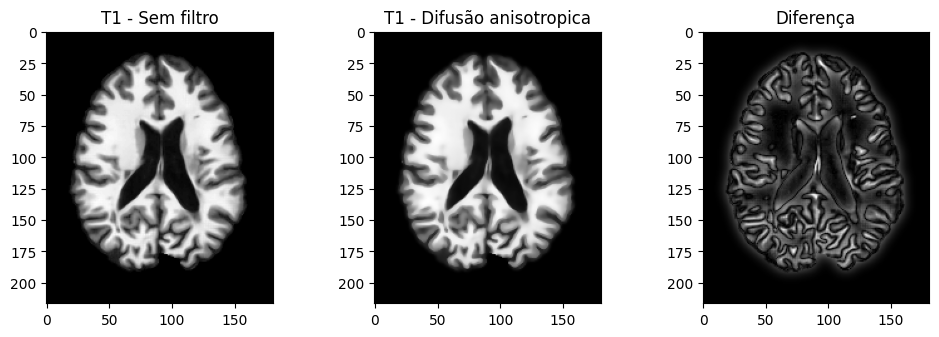

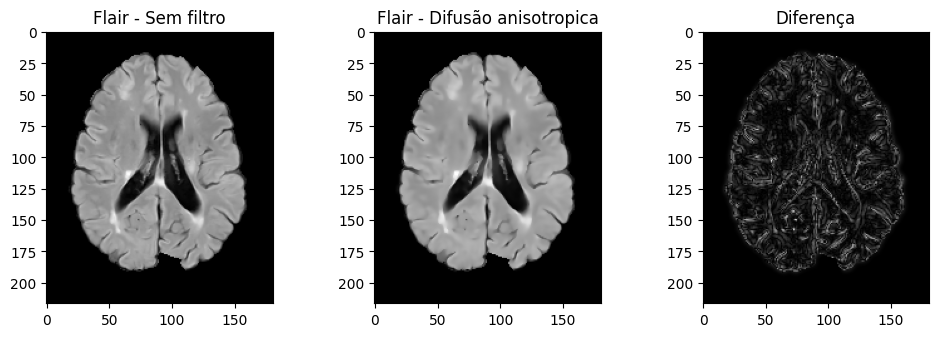

In [168]:
#pega a fatia e tranforma em itk
noisy_img = sitk.GetImageFromArray(img_array[slice_img_idx].astype("float32"))

denoised_img = sitk.GradientAnisotropicDiffusion(noisy_img, 0.125, 1.0, 10)

denoised_img_array = sitk.GetArrayFromImage(denoised_img)


#Mostra as imagens
plt.figure(figsize=[12,12])
plt.subplot(3,3,1)
plt.title("T1 - Sem filtro")
plt.imshow(img_array[slice_img_idx], 'gray')

plt.subplot(3,3,2)
plt.title("T1 - Difusão anisotropica")
plt.imshow(denoised_img_array, 'gray')

plt.subplot(3,3,3)
plt.title("Diferença")
plt.imshow(G_img, 'gray')



#pega a fatia e tranforma em itk
noisy_flair = sitk.GetImageFromArray(flair_array[slice_flair_idx].astype("float32"))

denoised_flair = sitk.GradientAnisotropicDiffusion(noisy_flair, 0.125, 1, 10)

denoised_flair_array = sitk.GetArrayFromImage(denoised_flair)

#Mostra as imagens
plt.figure(figsize=[12,12])
plt.subplot(3,3,1)
plt.title("Flair - Sem filtro")
plt.imshow(flair_array[slice_flair_idx], 'gray')

plt.subplot(3,3,2)
plt.title("Flair - Difusão anisotropica")
plt.imshow(denoised_flair_array, 'gray')

plt.subplot(3,3,3)
plt.title("Diferença")
plt.imshow(G_flair, 'gray')

In [ ]:
#pega a fatia e tranforma em itk
noisy_img = sitk.GetImageFromArray(img_array[slice_img_idx].astype("float32"))

denoised_img = sitk.denoisg(noisy_img, 0.125, 1.0, 10)

denoised_img_array = sitk.GetArrayFromImage(denoised_img)


#Mostra as imagens
plt.figure(figsize=[12,12])
plt.subplot(3,3,1)
plt.title("T1 - Sem filtro")
plt.imshow(img_array[slice_img_idx], 'gray')

plt.subplot(3,3,2)
plt.title("T1 - Difusão anisotropica")
plt.imshow(denoised_img_array, 'gray')

plt.subplot(3,3,3)
plt.title("Diferença")
plt.imshow(G_img, 'gray')



#pega a fatia e tranforma em itk
noisy_flair = sitk.GetImageFromArray(flair_array[slice_flair_idx].astype("float32"))

denoised_flair = sitk.GradientAnisotropicDiffusion(noisy_flair, 0.125, 1, 10)

denoised_flair_array = sitk.GetArrayFromImage(denoised_flair)

#Mostra as imagens
plt.figure(figsize=[12,12])
plt.subplot(3,3,1)
plt.title("Flair - Sem filtro")
plt.imshow(flair_array[slice_flair_idx], 'gray')

plt.subplot(3,3,2)
plt.title("Flair - Difusão anisotropica")
plt.imshow(denoised_flair_array, 'gray')

plt.subplot(3,3,3)
plt.title("Diferença")
plt.imshow(G_flair, 'gray')